kita bakal ngobrolin image dari dasar banget

gambar di komputer basically cuman sebuah numpy array aja, dengan range 0 sampai 255

In [2]:
import cv2
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [34]:
gambar_kecil = np.array([
    [0,   20,   40, 60,   80],
    [100,   120, 140, 160, 180],
    [200, 220, 240, 255, 256],
    [80,   0,   255, 0,   50000]
], dtype=np.uint8)

print(gambar_kecil)
print("\n tinggi dan lebar):", gambar_kecil.shape) 

"""
shape ini susunannya (panjang x lebar) atau dalam matrix (baris x kolom)
jadai gambar_kecil itu ukurannya 4 baris dan 5 kolom (4, 5)
"""

gambar_res = cv2.resize(gambar_kecil, (400, 400), interpolation=cv2.INTER_NEAREST)
cv2.imshow("Visualisasi Matriks ke Gambar", gambar_res)
cv2.waitKey(0)
cv2.destroyAllWindows()

[[  0  20  40  60  80]
 [100 120 140 160 180]
 [200 220 240 255   0]
 [ 80   0 255   0  80]]

 tinggi dan lebar): (4, 5)


In [4]:
# nah tadi itu kita liat gambar yang biner, coba kita import gambar yang keliatannya item putih
tulisanTangan = cv2.imread("Asset/tulisanTangan.png")
print(tulisanTangan)

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[181 183 184]
  [197 200 202]
  [195 198 200]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[239 240 240]
  [243 243 244]
  [241 242 243]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


wait, kenapa kita dapet bentuk array yang berbeda?

kenapa satu pixel isinya tiga angka, bukan satu? Karena secara default, OpenCV membaca semua gambar sebagai gambar berwarna (3 Channels: Blue, Green, Red)

coba kita pastiin lewat shape

In [5]:
print(tulisanTangan[0, 0])
print(tulisanTangan.shape)

[255 255 255]
(749, 500, 3)


bisa diliat kalau ada kolom ketiga dan didalamnya tertulis angka 3

ini disebut sebagai channels. jadi channels ini berperan sebagai tumpukan layer, terdiri dari Merah, Hijau, Biru (RGB) tapi kalau di cv2 ditulisnya GBR (green, blue, red).

coba kita liat contoh dibawah biar jelas, again rangenya itu dari 0 sampai 255

In [35]:
import cv2
import numpy as np

# Kita buat gambar 3x3 pixel tapi berwarna (3 channel)
# Format: [Blue, Green, Red]
warna_warni = np.array([
    [[255, 0, 0], [0, 255, 0], [0, 0, 255]],    # Baris 1: Biru, Hijau, Merah
    [[255, 255, 0], [0, 255, 255], [255, 0, 255]], # Baris 2: Cyan, Yellow, Magenta
    [[255, 255, 255], [0, 0, 0], [128, 128, 128]]  # Baris 3: Putih, Hitam, Abu-abu
], dtype=np.uint8)

res = cv2.resize(warna_warni, (300, 300), interpolation=cv2.INTER_NEAREST)

cv2.imshow("Dunia Berwarna BGR", res)
cv2.waitKey(0)
cv2.destroyAllWindows()
print("Bentuk Matriks Berwarna:", warna_warni.shape)
# Outputnya bakal (3, 3, 3) => Tinggi, Lebar, Jumlah Channel

Bentuk Matriks Berwarna: (3, 3, 3)


Gimana kalau kita mau bikin jadi 1 lapis (grayscale)? 

ada 2 cara
1. pas baca gambar kita taro angka 0 setelah menulis path file
2. kita pake fungsi konversi ini paling umum 

In [7]:
# ini_bakal_gray = cv2.imread("Asset/tulisanTangan.png", 0) # ga gweh run, males

# ini fungsi konversinya
tulisan_abuabu = cv2.cvtColor(tulisanTangan, cv2.COLOR_BGR2GRAY)
print(tulisanTangan.shape) 
print(tulisan_abuabu.shape) 

cv2.imshow("Dunia Berwarna BGR", tulisan_abuabu)
cv2.waitKey(0)
cv2.destroyAllWindows()

(749, 500, 3)
(749, 500)


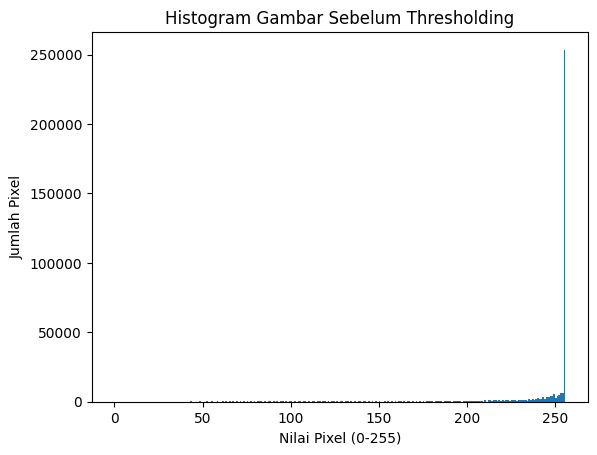

In [8]:
from matplotlib import pyplot as plt
# Kita hitung ada berapa banyak pixel untuk tiap angka 0-255
plt.hist(tulisan_abuabu.ravel(), 256, [0, 256])
plt.title("Histogram Gambar Sebelum Thresholding")
plt.xlabel("Nilai Pixel (0-255)")
plt.ylabel("Jumlah Pixel")
plt.show()

Ada 3 cara (yang gw tulis) buat bikin gambar tadi jadi biner

1. Binary Threshold: ini kita manual naro batasnya sendiri


In [9]:
# kita taro batasnya 127. Di atas 127 jadi 255, di bawah jadi 0.
ret1, thresh_manual = cv2.threshold(tulisan_abuabu, 127, 255, cv2.THRESH_BINARY)

2. Otsu's Threshold: ini algoritma yang nyari sendiri angka batas paling pas berdasarkan "lembah" di histogra

In [10]:
ret2, thresh_otsu = cv2.threshold(tulisan_abuabu, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu memutusakan batasnya adalah: {ret2}")

Otsu memutusakan batasnya adalah: 182.0


3. Adaptive Threshold: ini buat kalau ada bayangan (sebelah terang, sebelah gelap), kita pakai ini. dia bakal bagi gambar jadi kotak-kotak kecil dan nentuin threshold di tiap kotak

In [11]:
thresh_adaptive = cv2.adaptiveThreshold(tulisan_abuabu, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                        cv2.THRESH_BINARY, 11, 2)

In [38]:
perbandingan = np.hstack((tulisan_abuabu, thresh_manual, thresh_otsu, thresh_adaptive))
skala = 1200 / perbandingan.shape[1]
lebar = int(perbandingan.shape[1] * skala)
tinggi = int(perbandingan.shape[0] * skala)
perbandingan_res = cv2.resize(perbandingan, (lebar, tinggi))

cv2.imshow("Perbandingan Resized", perbandingan_res)
cv2.waitKey(0)
cv2.destroyAllWindows()

Kita liat kan kayak di Otsu ada bintik bintik putih, kita bisa ilangin dengan operasi morphologi.

kita kenalan dengan erosi dan dilasi:

- Erosi (cv2.erode): Mengikis tepi kayak namanya erosi, kita ngikis area hitam

- Dilatasi (cv2.dilate): lawannya erosi ini kita menebalkan tepi objek. Ibaratnya "menggemukkan" objek putih. Fungsinya untuk menyambung garis yang terputus

kita bisa kombinasiin penggunaan erosi dan dilasi kita biasanya sebut, Opening & Closing :

Opening (Erosi, Dilatasi)

Closing (Dilatasi, Erosi)


In [43]:
# kita pake thresh_otsu
"""
kita harus bikin "kuas"nya dulu, ukuran 3x3. kayak
"""

kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(thresh_otsu, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(thresh_otsu, cv2.MORPH_CLOSE, kernel)
hasil_morph = np.hstack((thresh_otsu, opening, closing))
cv2.imshow("Original Biner vs Opening vs Closing", hasil_morph)
cv2.waitKey(0)

-1

abis gambarnya bersih, kita bisa hitung objek dengan bikin komputer kita mengenali bentuk terus yaudah kita itung
kita sebut ini sebagai Contour Detection

countour (dictionary: "an outline, especially one representing or bounding the shape or form of something"), 

itu adalah garis yang menghubungkan semua titik berkesinambungan di sepanjang batas objek, yang memiliki warna atau intensitas yang sama. misal kita kalau liat logo, kita bisa bedain mana background dan foreground karena ada garis tepi kan? ya kira kira gitu

algoritmanya namanya findContours

tapi di OpenCV dia itu mencari objek berwarna Putih di atas latar Hitam. Jadi, jadi karena tulisan tangannya tadi yang hitam di atas kertas yang putih, kita harus me-inverse (membalik) warnanya dulu

In [44]:
img_biner = cv2.bitwise_not(closing) # ini buat nge inverse warna

"""
cari countour
- cv2.RETR_EXTERNAL: Hanya ambil kontur terluar saja
- cv2.CHAIN_APPROX_SIMPLE: Menghemat memori dengan hanya menyimpan titik sudut
"""
contours, hierarchy = cv2.findContours(img_biner, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

foto_asli = cv2.imread("Asset/tulisanTangan.png")

for cnt in contours:
    # Ambil koordinat kotak pembungkus (Bounding Box)
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Filter: Hanya gambar kotak jika ukurannya cukup besar (menghindari noise kecil)
    if w > 10 and h > 10:
        cv2.rectangle(foto_asli, (x, y), (x + w, y + h), (0, 255, 0), 2)

print(f"Jumlah objek (huruf/kata) yang dideteksi: {len(contours)}")

cv2.imshow("Deteksi Objek", foto_asli)
cv2.waitKey(0)

Jumlah objek (huruf/kata) yang dideteksi: 457


-1

hmm, tapi kita mau liat kata katanya kan? 

kita kan punya koordinat $(x, y, w, h)$ dari proses kontur tadi, kita bisa melakukan Cropping

ini bisa dilakukan karena kembali lagi ke konsep awal: Gambar adalah Matriks. Memotong gambar sama saja dengan mengambil sebagian baris dan kolom dari matriks tersebut

In [ ]:
import os
"""
Jika gambar asli adalah matriks img, maka cara memotongnya adalah:
potongan = img[y_awal : y_akhir, x_awal : x_akhir]

Sesuai dengan kotak yang kita dapat dari boundingRect:

y_awal adalah y

y_akhir adalah y + h

x_awal adalah x

x_akhir adalah x + w
"""

if not os.path.exists('hasil_huruf'):
    os.makedirs('hasil_huruf')

count = 0
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Filter ukuran agar tidak memproses debu/noise
    if w > 10 and h > 10:
        # 1. CROP dari gambar asli (bukan dari gambar biner agar hasilnya berwarna)
        huruf_crop = foto_asli[y:y+h, x:x+w]
        
        # 2. SIMPAN ke folder
        nama_file = f"hasil_huruf/huruf_{count}.png"
        cv2.imwrite(nama_file, huruf_crop)
        
        # 3. Gambar kotak di foto_asli buat penanda
        cv2.rectangle(foto_asli, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        count += 1

print(f"Selesai! {count} huruf telah dipotong dan disimpan di folder 'hasil_huruf'.")

Foreground VS Background


In [45]:
import cv2
import numpy as np

roblox = cv2.imread("Asset/roblox.png")
gray = cv2.cvtColor(roblox, cv2.COLOR_BGR2GRAY)

gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
vis1 = np.hstack((roblox, gray_3ch))
cv2.imshow("1. Asli vs Grayscale", vis1)
cv2.waitKey(0)

-1

In [46]:
# Otsu Thresholding
# Coba pakai THRESH_BINARY_INV
ret, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
vis2 = np.hstack((gray_3ch, mask_3ch))
cv2.imshow("2. Grayscale vs Mask", vis2)
cv2.waitKey(0)

-1

In [48]:
# 4. Closing (Dilasi lalu Erosi) untuk menutup lubang di dalam objek
kernel = np.ones((5,5), np.uint8)
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Visualisasi step 3
mask_clean_3ch = cv2.cvtColor(mask_clean, cv2.COLOR_GRAY2BGR)
vis3 = np.hstack((mask_3ch, mask_clean_3ch))
cv2.imshow("3. Mask Kotor vs Mask Bersih", vis3)
cv2.waitKey(0)

-1

In [52]:
foreground = cv2.bitwise_and(roblox, roblox, mask=mask_clean)

# Visualisasi Final
vis_final = np.hstack((roblox, foreground))
cv2.imshow("4. HASIL AKHIR: Background Terbuang!", vis_final)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [53]:
cv2.imshow("Cek Mask Kamu", mask_clean)
cv2.waitKey(0)

-1